Accuracy: 0.9649122807017544


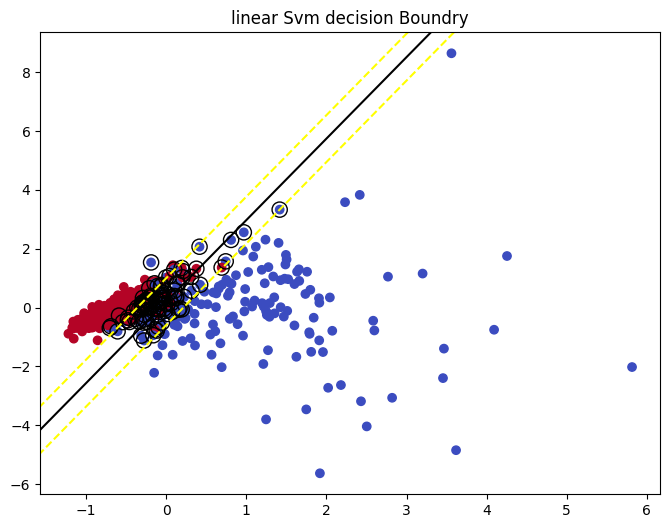

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X=data.data
y=data.target


pca = PCA(n_components=2)
X = pca.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = SVC(kernel="linear", C=1)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


def plot_svm(model, X, y):
    plt.figure(figsize=(8,6))
    plt.scatter(X[:,0],X[:,1],c=y,cmap="coolwarm")
    
    
    ax = plt.gca()

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    
    YY, XX = np.meshgrid(yy, xx)

    xy =np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy)
    Z = Z.reshape(XX.shape)
    
    ax.contour(XX, YY, Z, levels=[0], colors="black")
    
    # margin lines
    ax.contour(XX, YY, Z, levels=[-1,1], colors="Yellow", linestyles="dashed")
    
   
    ax.scatter(
        model.support_vectors_[:,0],
        model.support_vectors_[:,1],
        s=120,
        facecolors="none",
        edgecolors="black"
    )

    plt.title("linear Svm decision Boundry")
    plt.show()

plot_svm(model, X_train, y_train)
        